In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

print("UCI Diabetes Dataset:", uci_diabetes.shape)
print("Pima Indians Diabetes Dataset:", pima_diabetes.shape)

UCI Diabetes Dataset: (768, 8)
Pima Indians Diabetes Dataset: (768, 8)


In [5]:
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

print("Features:", features)
print("Target:", target)

Features: ['Glucose', 'BloodPressure', 'BMI']
Target: Outcome


In [6]:
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

print("UCI Training:", X_train_uci.shape)
print("UCI Testing:", X_test_uci.shape)

print("Pima Training:", X_train_pima.shape)
print("Pima Testing:", X_test_pima.shape)

UCI Training: (614, 3)
UCI Testing: (154, 3)
Pima Training: (614, 3)
Pima Testing: (154, 3)


In [7]:
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

print("UCI Logistic Regression model trained successfully.")
print("Pima Logistic Regression model trained successfully.")

UCI Logistic Regression model trained successfully.
Pima Logistic Regression model trained successfully.


In [8]:
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

print("First 10 UCI predictions:")
print(y_pred_uci[:10])

print("\nFirst 10 Pima predictions:")
print(y_pred_pima[:10])

First 10 UCI predictions:
[0 0 0 0 0 0 0 0 1 1]

First 10 Pima predictions:
[0 0 0 0 0 0 0 0 1 1]


In [9]:
accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci, zero_division=0)
recall_uci = recall_score(y_test_uci, y_pred_uci, zero_division=0)
f1_uci = f1_score(y_test_uci, y_pred_uci, zero_division=0)

accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima, zero_division=0)
recall_pima = recall_score(y_test_pima, y_pred_pima, zero_division=0)
f1_pima = f1_score(y_test_pima, y_pred_pima, zero_division=0)

print("UCI Diabetes Dataset - Logistic Regression Results:")
print(f"Accuracy: {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall: {recall_uci:.4f}")
print(f"F1 Score: {f1_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Logistic Regression Results:")
print(f"Accuracy: {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall: {recall_pima:.4f}")
print(f"F1 Score: {f1_pima:.4f}")

UCI Diabetes Dataset - Logistic Regression Results:
Accuracy: 0.7662
Precision: 0.6939
Recall: 0.6182
F1 Score: 0.6538

Pima Indians Diabetes Dataset - Logistic Regression Results:
Accuracy: 0.7662
Precision: 0.6939
Recall: 0.6182
F1 Score: 0.6538


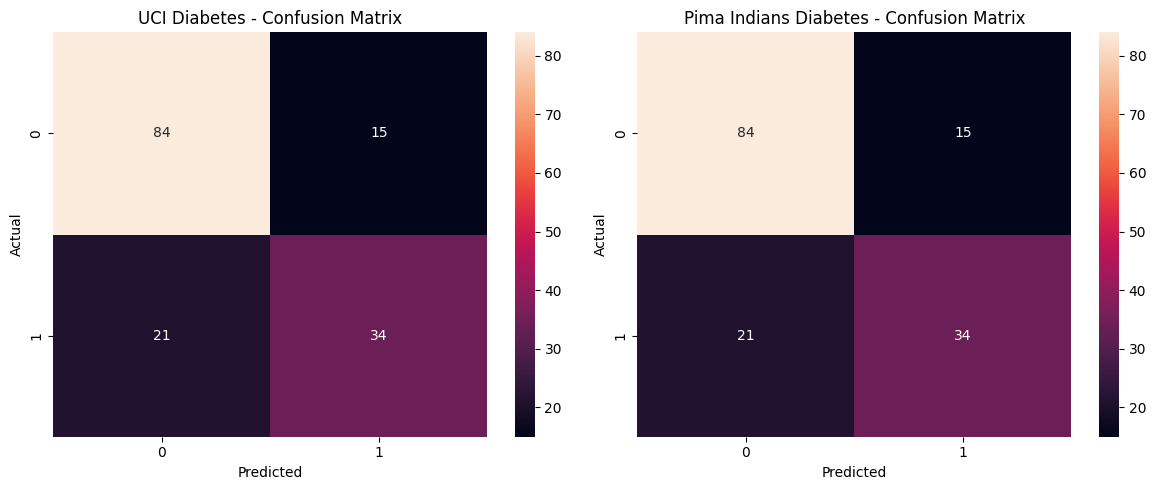

In [10]:
cm_uci = confusion_matrix(y_test_uci, y_pred_uci)
cm_pima = confusion_matrix(y_test_pima, y_pred_pima)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_uci, annot=True, fmt="d", ax=axes[0])
axes[0].set_title("UCI Diabetes - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_pima, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Pima Indians Diabetes - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()